In [1]:
import pandas as pd
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt

df_branded = pd.read_csv('branded_food.csv')

df_branded.head()

C:\Users\yitho\AppData\Local\Temp\ipykernel_13608\2080874012.py:6: DtypeWarning: Columns (2,3,4,6,12,16,17,18,19) have mixed types. Specify dtype option on import or set low_memory=False.
  df_branded = pd.read_csv('branded_food.csv')


,fdc_id,brand_owner,brand_name,subbrand_name,gtin_upc,ingredients,not_a_significant_source_of,serving_size,serving_size_unit,household_serving_fulltext,...,data_source,package_weight,modified_date,available_date,market_country,discontinued_date,preparation_state_code,trade_channel,short_description,material_code
0,1105904,Richardson Oilseed Products (US) Limited,NaN,NaN,27000612323,Vegetable Oil,NaN,15.0,ml,1 Tbsp (15 ml),...,GDSN,NaN,2020-10-02,2020-11-13,United States,NaN,NaN,NaN,NaN,NaN
1,1105905,CAMPBELL SOUP COMPANY,NaN,NaN,51000198808,"INGREDIENTS: BEEF STOCK, CONTAINS LESS THAN 2%...",NaN,240.0,ml,Amount per serving,...,GDSN,NaN,2020-09-12,2020-11-13,United States,NaN,NaN,NaN,NaN,NaN
2,1105906,CAMPBELL SOUP COMPANY,NaN,NaN,51000213273,"INGREDIENTS: CLAM STOCK, POTATOES, CLAMS, CREA...",NaN,440.0,g,PER CONTAINER,...,GDSN,NaN,2020-09-01,2020-11-13,United States,NaN,NaN,NaN,NaN,NaN
3,1105907,CAMPBELL SOUP COMPANY,NaN,NaN,51000213303,"INGREDIENTS: WATER, CREAM, BROCCOLI, CELERY, V...",NaN,440.0,g,PER CONTAINER,...,GDSN,NaN,2020-09-01,2020-11-13,United States,NaN,NaN,NaN,NaN,NaN
4,1105908,CAMPBELL SOUP COMPANY,NaN,NaN,51000224637,"INGREDIENTS: CHICKEN STOCK, CONTAINS LESS THAN...",NaN,240.0,ml,Amount per Serving,...,GDSN,NaN,2020-10-03,2020-11-13,United States,NaN,NaN,NaN,NaN,NaN


In [2]:
print(df_branded.shape)
print(df_branded.columns)


(1993975, 21)
Index(['fdc_id', 'brand_owner', 'brand_name', 'subbrand_name', 'gtin_upc',
       'ingredients', 'not_a_significant_source_of', 'serving_size',
       'serving_size_unit', 'household_serving_fulltext',
       'branded_food_category', 'data_source', 'package_weight',
       'modified_date', 'available_date', 'market_country',
       'discontinued_date', 'preparation_state_code', 'trade_channel',
       'short_description', 'material_code'],
      dtype='object')


In [3]:
df_branded.isna().sum()

fdc_id                               0
brand_owner                      17251
brand_name                      544896
subbrand_name                  1887393
gtin_upc                             0
ingredients                       5373
not_a_significant_source_of    1914360
serving_size                     10755
serving_size_unit                18992
household_serving_fulltext       41354
branded_food_category            10630
data_source                          0
package_weight                 1133565
modified_date                       20
available_date                       0
market_country                       0
discontinued_date              1990510
preparation_state_code         1895482
trade_channel                  1956108
short_description              1895392
material_code                  1992652
dtype: int64

In [4]:
df_food_nutrient = pd.read_csv('food_nutrient.csv')
print(df_food_nutrient.head())

         id   fdc_id  nutrient_id  amount  data_points  derivation_id  min  \
0  13706927  1105904         1257    0.00          NaN           71.0  NaN   
1  13706930  1105904         1293   53.33          NaN           71.0  NaN   
2  13706926  1105904         1253    0.00          NaN           75.0  NaN   
3  13706921  1105904         1092    0.00          NaN           75.0  NaN   
4  13706916  1105904         1008  867.00          NaN           71.0  NaN   

   max  median  footnote  min_year_acquired  
0  NaN     NaN       NaN                NaN  
1  NaN     NaN       NaN                NaN  
2  NaN     NaN       NaN                NaN  
3  NaN     NaN       NaN                NaN  
4  NaN     NaN       NaN                NaN  


In [5]:
df_food_nutrient.shape

(25937630, 11)

In [6]:
#Create new df that contains rows with 'protien' in ingredients
df_protein = df_branded[df_branded['ingredients'].str.contains('protein', case=False, na=False)].copy()

In [7]:
print(df_protein.head(), df_protein.shape)

      fdc_id            brand_owner brand_name subbrand_name     gtin_upc  \
2    1105906  CAMPBELL SOUP COMPANY        NaN           NaN  51000213273   
3    1105907  CAMPBELL SOUP COMPANY        NaN           NaN  51000213303   
31   1105935        PEPPERIDGE FARM        NaN           NaN  14100074625   
109  1106013  CAMPBELL SOUP COMPANY        NaN           NaN  51000270436   
110  1106014  CAMPBELL SOUP COMPANY        NaN           NaN  51000270467   

                                           ingredients  \
2    INGREDIENTS: CLAM STOCK, POTATOES, CLAMS, CREA...   
3    INGREDIENTS: WATER, CREAM, BROCCOLI, CELERY, V...   
31   MADE FROM: ENRICHED WHEAT FLOUR (FLOUR, NIACIN...   
109  INGREDIENTS: WATER, CHICKEN STOCK, SPAETZLE DU...   
110  INGREDIENTS: WATER, BEEF STOCK, CARROTS, POTAT...   

    not_a_significant_source_of  serving_size serving_size_unit  \
2                           NaN         440.0                 g   
3                           NaN         440.0         

In [8]:
df_protien_category = df_branded[df_branded['branded_food_category'].str.contains('protein',case=False,na=False)]

In [9]:
print(df_protien_category.shape,df_protien_category.head())

(10490, 21)        fdc_id                    brand_owner brand_name subbrand_name  \
3842  1109782               The Daily Record        NaN           NaN   
3865  1109805               The Daily Record        NaN           NaN   
3912  1109852               The Daily Record        NaN           NaN   
4453  1110412  Ocean Spray Cranberries, Inc.        NaN           NaN   
4522  1110482           Garden of Life, Inc.        NaN           NaN   

          gtin_upc                                        ingredients  \
3842  838766005560  PEA PROTEIN, WHOLE FLAXSEED (MICROMILLED), ORG...   
3865  838766005201  PEA PROTEIN, WHOLE FLAXSEED (MICROMILLED), COC...   
3912  838766005317  PEA PROTEIN, WHOLE FLAXSEED (MICROMILLED), ORG...   
4453   31200002235  INGREDIENTS: FILTERED WATER, GRAPE JUICE (WATE...   
4522  658010118170  CERTIFIED ORGANIC PLANT PROTEIN BLEND: [ORGANI...   

     not_a_significant_source_of  serving_size serving_size_unit  \
3842                         NaN          

In [10]:
df_protien_category['branded_food_category'].unique().tolist()

['Energy, Protein & Muscle Recovery Drinks',
 'Includes all products which can be described/observed as a healthy food alternative to meat vegetable and egg proteins. These products are non animal based and an imitation of meat products, meant to simulate the taste and mouthfeel of real meat but are normally made from a combination of non animal based ingredients. Includes products such as soya, fungus, beans, lentils, peas and chickpeas based products. These products must be frozen to extend their consumable life.']

In [11]:
df_protein_drinks = df_protien_category[df_protien_category['branded_food_category'] == 'Energy, Protein & Muscle Recovery Drinks']

In [12]:
print(df_protein_drinks.shape)

(10488, 21)


In [13]:
df_protein_drinks.columns

cols = ['fdc_id', 'brand_owner','ingredients','serving_size','serving_size_unit']

df_protein_drinks = df_protein_drinks[cols]

In [14]:
df_protein_drinks

#Create new df that contains rows with 'protien' in ingredients
df_protein_drinks = df_protein_drinks[df_protein_drinks['ingredients'].str.contains('protein', case=False, na=False)].copy()

In [15]:
df_protein_drinks.shape

(9111, 5)

In [16]:
df_protein_drinks.head(10)

,fdc_id,brand_owner,ingredients,serving_size,serving_size_unit
3842,1109782,The Daily Record,"PEA PROTEIN, WHOLE FLAXSEED (MICROMILLED), ORG...",42.0,g
3865,1109805,The Daily Record,"PEA PROTEIN, WHOLE FLAXSEED (MICROMILLED), COC...",46.0,g
3912,1109852,The Daily Record,"PEA PROTEIN, WHOLE FLAXSEED (MICROMILLED), ORG...",42.0,g
4522,1110482,"Garden of Life, Inc.",CERTIFIED ORGANIC PLANT PROTEIN BLEND: [ORGANI...,27.5,g
4549,1110509,"Atkins Nutritionals, Inc.","INGREDIENTS: WATER, DAIRY PROTEIN BLEND (MILK ...",325.0,ml
8634,1114610,"Atkins Nutritionals, Inc.","INGREDIENTS: WATER, DAIRY PROTEIN BLEND (MILK ...",325.0,ml
8636,1114612,"Atkins Nutritionals, Inc.","INGREDIENTS: WATER, DAIRY PROTEIN BLEND (MILK ...",325.0,ml
9531,1115579,Abbott Laboratories Inc,"WATER, CORN MALTODEXTRIN, SUGAR, BLEND OF VEGE...",237.0,ml
9648,1115715,"Atkins Nutritionals, Inc.","INGREDIENTS: WATER, DAIRY PROTEIN BLEND (MILK ...",325.0,ml
10793,1116903,Abbott Laboratories Inc,"INGREDIENTS: WATER, CORN MALTODEXTRIN, SUGAR, ...",240.0,ml


In [17]:
# Merge the protein data to the nutrients
df_combined = pd.merge(df_protein_drinks, df_food_nutrient, on='fdc_id', how='inner')

In [18]:
#df_combined

In [19]:
df_combined['nutrient_id'].dtype
print(df_combined['nutrient_id'].unique())

[1090 1103 1089 1166 1091 1167 1110 1004 1178 1177 1253 1258 1008 1185
 1093 1175 1162 2000 1092 1087 1005 1104 1165 1170 1003 1079 1095 1100
 1102 1098 1101 1257 1293 1292 1235 1186 1158 1096 1176 1082 1084 1086
 1214 1226 1220 1217 1219 1223 1232 1212 1211 1210 1227 1225 1222 1221
 1213 1224 1215 1218 1216 1233 1051 1088 1234 1180 1181 1072 1078 1109
 1190 1063 1114 1106 2068]


In [20]:
# Use integers instead of strings
nutrients = [1003,1004,1005,1008]

# Filter the combined DataFrame
df_combined_filtered = df_combined[df_combined['nutrient_id'].isin(nutrients)].copy()

In [21]:
df_combined_filtered

,fdc_id,brand_owner,ingredients,serving_size,serving_size_unit,id,nutrient_id,amount,data_points,derivation_id,min,max,median,footnote,min_year_acquired
7,1109782,The Daily Record,"PEA PROTEIN, WHOLE FLAXSEED (MICROMILLED), ORG...",42.0,g,13723706,1004,14.29,NaN,70.0,NaN,NaN,NaN,NaN,NaN
12,1109782,The Daily Record,"PEA PROTEIN, WHOLE FLAXSEED (MICROMILLED), ORG...",42.0,g,13723708,1008,381.00,NaN,70.0,NaN,NaN,NaN,NaN,NaN
20,1109782,The Daily Record,"PEA PROTEIN, WHOLE FLAXSEED (MICROMILLED), ORG...",42.0,g,13723707,1005,23.81,NaN,70.0,NaN,NaN,NaN,NaN,NaN
24,1109782,The Daily Record,"PEA PROTEIN, WHOLE FLAXSEED (MICROMILLED), ORG...",42.0,g,13723705,1003,47.62,NaN,70.0,NaN,NaN,NaN,NaN,NaN
27,1109805,The Daily Record,"PEA PROTEIN, WHOLE FLAXSEED (MICROMILLED), COC...",46.0,g,13723732,1005,28.26,NaN,70.0,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
181610,2678886,The Quaker Oats Co./gatorade-Van Camp,"WATER, MILK PROTEIN ISOLATE, SUGAR, NATURAL AN...",330.0,MLT,33592651,1004,0.30,NaN,70.0,NaN,NaN,NaN,NaN,NaN
181614,2678889,The Quaker Oats Co./gatorade-Van Camp,"WATER, WHEY PROTEIN ISOLATE, CITRIC ACID, NATU...",500.0,MLT,33592775,1004,0.00,NaN,70.0,NaN,NaN,NaN,NaN,NaN
181618,2678889,The Quaker Oats Co./gatorade-Van Camp,"WATER, WHEY PROTEIN ISOLATE, CITRIC ACID, NATU...",500.0,MLT,33592774,1003,2.00,NaN,70.0,NaN,NaN,NaN,NaN,NaN
181619,2678889,The Quaker Oats Co./gatorade-Van Camp,"WATER, WHEY PROTEIN ISOLATE, CITRIC ACID, NATU...",500.0,MLT,33592776,1005,0.20,NaN,70.0,NaN,NaN,NaN,NaN,NaN


In [22]:
print(df_combined_filtered.columns,df_combined_filtered.head())

Index(['fdc_id', 'brand_owner', 'ingredients', 'serving_size',
       'serving_size_unit', 'id', 'nutrient_id', 'amount', 'data_points',
       'derivation_id', 'min', 'max', 'median', 'footnote',
       'min_year_acquired'],
      dtype='object')      fdc_id       brand_owner  \
7   1109782  The Daily Record   
12  1109782  The Daily Record   
20  1109782  The Daily Record   
24  1109782  The Daily Record   
27  1109805  The Daily Record   

                                          ingredients  serving_size  \
7   PEA PROTEIN, WHOLE FLAXSEED (MICROMILLED), ORG...          42.0   
12  PEA PROTEIN, WHOLE FLAXSEED (MICROMILLED), ORG...          42.0   
20  PEA PROTEIN, WHOLE FLAXSEED (MICROMILLED), ORG...          42.0   
24  PEA PROTEIN, WHOLE FLAXSEED (MICROMILLED), ORG...          42.0   
27  PEA PROTEIN, WHOLE FLAXSEED (MICROMILLED), COC...          46.0   

   serving_size_unit        id  nutrient_id  amount  data_points  \
7                  g  13723706         1004   14.29       

In [23]:
# Pivot to move nutrients to columns
df_pivoted = df_combined_filtered.pivot_table(
    index=['fdc_id'], 
    columns='nutrient_id', 
    values='amount'
).reset_index()

# Rename columns to be human-readable
# 1003: Protein, 1004: Fat, 1005: Carbs, 1008: Calories
df_pivoted = df_pivoted.rename(columns={
    1003: 'protein',
    1004: 'fat',
    1005: 'carbs',
    1008: 'calories'
})

In [24]:
df_pivoted

nutrient_id,fdc_id,protein,fat,carbs,calories
0,399553,71.43,7.14,17.86,393.0
1,402940,64.52,8.06,12.90,355.0
2,403200,46.51,16.28,25.58,442.0
3,403243,65.22,8.70,13.04,391.0
4,405035,51.28,15.38,20.51,385.0
...,...,...,...,...,...
8322,2678846,2.00,0.00,0.20,12.0
8323,2678868,6.06,0.45,4.55,42.0
8324,2678884,6.06,0.61,4.85,42.0
8325,2678886,9.09,0.30,3.33,55.0


In [25]:
df_branded.columns

Index(['fdc_id', 'brand_owner', 'brand_name', 'subbrand_name', 'gtin_upc',
       'ingredients', 'not_a_significant_source_of', 'serving_size',
       'serving_size_unit', 'household_serving_fulltext',
       'branded_food_category', 'data_source', 'package_weight',
       'modified_date', 'available_date', 'market_country',
       'discontinued_date', 'preparation_state_code', 'trade_channel',
       'short_description', 'material_code'],
      dtype='object')

In [26]:
# Assuming df_branded is your loaded branded_food.csv
df_final = df_pivoted.merge(
    df_branded[['fdc_id', 'ingredients', 'serving_size','serving_size_unit']], 
    on='fdc_id', 
    how='inner'
)

In [27]:
df_final

,fdc_id,protein,fat,carbs,calories,ingredients,serving_size,serving_size_unit
0,399553,71.43,7.14,17.86,393.0,"DAIRY WHEY PROTEIN CONCENTRATE, ORGANIC COCOA*...",28.0,g
1,402940,64.52,8.06,12.90,355.0,"GREEN FOOD BLEND (ORGANIC WHEAT GRASS, ORGANIC...",31.0,g
2,403200,46.51,16.28,25.58,442.0,"GREEN FOOD BLEND (ORGANIC WHEAT GRASS, ORGANIC...",43.0,g
3,403243,65.22,8.70,13.04,391.0,CERTIFIED ORGANIC PLANT PROTEIN BLEND: [ORGANI...,23.0,g
4,405035,51.28,15.38,20.51,385.0,"PEA PROTEIN, WHOLE FLAXSEED (MICRO-MILLED), OR...",39.0,g
...,...,...,...,...,...,...,...,...
8322,2678846,2.00,0.00,0.20,12.0,"WATER, WHEY PROTEIN ISOLATE, CITRIC ACID, NATU...",500.0,MLT
8323,2678868,6.06,0.45,4.55,42.0,"WATER, PEA PROTEIN ISOLATE, SOLUBLE CORN FIBER...",330.0,MLT
8324,2678884,6.06,0.61,4.85,42.0,"WATER, PEA PROTEIN ISOLATE, SOLUBLE CORN FIBER...",330.0,MLT
8325,2678886,9.09,0.30,3.33,55.0,"WATER, MILK PROTEIN ISOLATE, SUGAR, NATURAL AN...",330.0,MLT


In [28]:
# Define keywords for categorization
animal_keywords = 'whey|casein|milk|egg|collagen|gelatin'
plant_keywords = 'pea|soy|rice|hemp|quinoa'

# Categorize the dataframe
df_final['source_type'] = 'Other'
df_final.loc[df_final['ingredients'].str.contains(animal_keywords, case=False, na=False), 'source_type'] = 'Animal'
df_final.loc[df_final['ingredients'].str.contains(plant_keywords, case=False, na=False), 'source_type'] = 'Plant'

# Filter to only the two groups we want to compare
df_final = df_final[df_final['source_type'].isin(['Animal', 'Plant'])]

In [29]:
df_final

,fdc_id,protein,fat,carbs,calories,ingredients,serving_size,serving_size_unit,source_type
0,399553,71.43,7.14,17.86,393.0,"DAIRY WHEY PROTEIN CONCENTRATE, ORGANIC COCOA*...",28.0,g,Animal
1,402940,64.52,8.06,12.90,355.0,"GREEN FOOD BLEND (ORGANIC WHEAT GRASS, ORGANIC...",31.0,g,Plant
2,403200,46.51,16.28,25.58,442.0,"GREEN FOOD BLEND (ORGANIC WHEAT GRASS, ORGANIC...",43.0,g,Plant
3,403243,65.22,8.70,13.04,391.0,CERTIFIED ORGANIC PLANT PROTEIN BLEND: [ORGANI...,23.0,g,Plant
4,405035,51.28,15.38,20.51,385.0,"PEA PROTEIN, WHOLE FLAXSEED (MICRO-MILLED), OR...",39.0,g,Plant
...,...,...,...,...,...,...,...,...,...
8322,2678846,2.00,0.00,0.20,12.0,"WATER, WHEY PROTEIN ISOLATE, CITRIC ACID, NATU...",500.0,MLT,Animal
8323,2678868,6.06,0.45,4.55,42.0,"WATER, PEA PROTEIN ISOLATE, SOLUBLE CORN FIBER...",330.0,MLT,Plant
8324,2678884,6.06,0.61,4.85,42.0,"WATER, PEA PROTEIN ISOLATE, SOLUBLE CORN FIBER...",330.0,MLT,Plant
8325,2678886,9.09,0.30,3.33,55.0,"WATER, MILK PROTEIN ISOLATE, SUGAR, NATURAL AN...",330.0,MLT,Animal


In [30]:
# Standardize protein per 100 calories
df_final['protein_per_100_cal'] = (df_final['protein'] / df_final['calories']) * 100

# Calculate Protein Purity (Percentage of calories from protein)
df_final['protein_purity'] = (df_final['protein'] * 4) / df_final['calories']

C:\Users\yitho\AppData\Local\Temp\ipykernel_13608\3339239280.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_final['protein_per_100_cal'] = (df_final['protein'] / df_final['calories']) * 100
C:\Users\yitho\AppData\Local\Temp\ipykernel_13608\3339239280.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_final['protein_purity'] = (df_final['protein'] * 4) / df_final['calories']


In [31]:
df_final['protein_per_100_cal'].head()

0    18.175573
1    18.174648
2    10.522624
3    16.680307
4    13.319481
Name: protein_per_100_cal, dtype: float64

In [32]:
df_final.isna().sum()

# Fill missing protein values using the mean of their specific source group (Animal or Plant)
df_final['protein'] = df_final['protein'].fillna(
    df_final.groupby('source_type')['protein'].transform('mean')
)

df_final = df_final.dropna(subset=['calories']).copy()

df_final.isna().sum()

C:\Users\yitho\AppData\Local\Temp\ipykernel_13608\1653537510.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_final['protein'] = df_final['protein'].fillna(


fdc_id                  0
protein                 0
fat                    45
carbs                  21
calories                0
ingredients             0
serving_size            0
serving_size_unit      36
source_type             0
protein_per_100_cal    39
protein_purity         39
dtype: int64

In [33]:
df_final[df_final['calories'] < 1].count()
df_final = df_final[df_final['calories'] > 1]

In [34]:
df_final.groupby('source_type')['protein_per_100_cal'].mean()

source_type
Animal    17.550847
Plant     11.028968
Name: protein_per_100_cal, dtype: float64

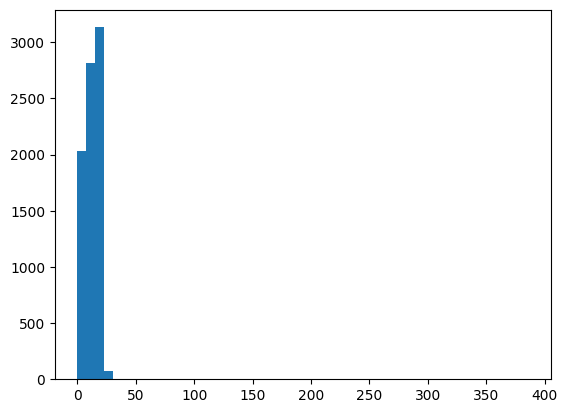

In [35]:
plt.hist(df_final['protein_per_100_cal'], bins = 50)
plt.show()

In [36]:
df_final['protein'].describe()
df_final[df_final['protein'] > 100]

,fdc_id,protein,fat,carbs,calories,ingredients,serving_size,serving_size_unit,source_type,protein_per_100_cal,protein_purity
1128,776268,238.75,283.75,473.75,5312.0,"WATER, CORN SYRUP SOLIDS, CASEINATES (CALCIUM,...",240.0,ml,Plant,4.494541,0.179782
1134,798049,162.50,137.50,637.50,4375.0,"WATER, CORN MALTODEXTRIN, SUGAR, MILK PROTEIN ...",240.0,ml,Plant,3.714286,0.148571
1166,805619,125.00,112.50,200.00,2250.0,"INGREDIENTS: WATER, MILK PROTEIN CONCENTRATE, ...",240.0,ml,Plant,5.555556,0.222222
1186,850670,133.33,83.33,433.33,3000.0,"SKIM MILK, SUGAR AND LESS THAN 2% OF CORN SYRU...",360.0,ml,Plant,4.444333,0.177773
1193,852452,125.00,87.50,325.00,2500.0,"WATER, CORN MALTODEXTRIN, MILK PROTEIN CONCENT...",240.0,ml,Plant,5.000000,0.200000
...,...,...,...,...,...,...,...,...,...,...,...
5311,2193706,272.73,27.27,36.36,1455.0,"WATER, MILK PROTEIN CONCENTRATE+, CALCIUM CASE...",330.0,ml,Animal,18.744330,0.749773
5417,2256153,181.82,27.27,118.18,1364.0,"WATER, MILK PROTEIN CONCENTRATE+, OATS+, SOLUB...",330.0,ml,Animal,13.329912,0.533196
5435,2265341,181.82,27.27,118.18,1364.0,"WATER, MILK PROTEIN CONCENTRATE+, OATS+, SOLUB...",330.0,ml,Animal,13.329912,0.533196
6165,2319817,145.45,63.64,290.91,2273.0,"FILTERED WATER, ORGAIN ORGANIC PROTEIN BLEND (...",330.0,ml,Plant,6.399032,0.255961


In [37]:
df_final[df_final['protein'] < 10].head(10)

,fdc_id,protein,fat,carbs,calories,ingredients,serving_size,serving_size_unit,source_type,protein_per_100_cal,protein_purity
42,411839,4.62,2.77,0.62,49.0,"WATER, DAIRY PROTEINBLEND (MILK PROTEIN CONCEN...",325.0,ml,Plant,9.428571,0.377143
44,432314,6.15,1.02,2.05,41.0,"WATER, CALCIUM SODIUM CASEINATE, MILK PROTEIN ...",244.0,ml,Plant,15.000000,0.600000
45,445189,2.92,3.75,13.33,100.0,"WATER, SUGAR (SUCROSE), MALTODEXTRIN (CORN), M...",240.0,ml,Plant,2.920000,0.116800
46,445225,2.92,3.75,13.33,100.0,"WATER, SUGAR (SUCROSE), MALTODEXTRIN (CORN), M...",240.0,ml,Plant,2.920000,0.116800
47,456751,4.62,2.77,0.92,49.0,"WATER, DAIRY PROTEIN BLEND (MILK PROTEIN CONCE...",325.0,ml,Plant,9.428571,0.377143
49,491996,4.62,3.08,1.85,49.0,"WATER, DAIRY PROTEIN BLEND (MILK PROTEIN CONCE...",325.0,ml,Plant,9.428571,0.377143
50,492922,5.63,2.25,7.89,70.0,"PURIFIED WATER, RUMBLE PROTEIN BLEND (MILK PRO...",355.0,ml,Animal,8.042857,0.321714
51,492929,5.63,2.25,7.89,70.0,"PURIFIED WATER, RUMBLE PROTEIN BLEND (MILK PRO...",355.0,ml,Animal,8.042857,0.321714
52,493969,6.06,0.76,4.85,42.0,FAIR TRADE CERTIFIED ORGANIC COCONUT WATER FRO...,330.0,ml,Animal,14.428571,0.577143
53,494208,6.15,1.23,3.28,49.0,"WATER, ORGANIC MILK PROTEIN CONCENTRATE, ORGAN...",244.0,ml,Animal,12.551020,0.502041


In [38]:
df_food = pd.read_csv('food.csv')

df_food.head()

C:\Users\yitho\AppData\Local\Temp\ipykernel_13608\966180207.py:1: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  df_food = pd.read_csv('food.csv')


,fdc_id,data_type,description,food_category_id,publication_date,market_country,trade_channel,microbe_data
0,1105904,branded_food,WESSON Vegetable Oil 1 GAL,NaN,2020-11-13,United States,NaN,"[{""min_value"":null,""uom"":null,""microbe_method""..."
1,1105905,branded_food,SWANSON BROTH BEEF,NaN,2020-11-13,United States,NaN,"[{""min_value"":null,""uom"":null,""microbe_method""..."
2,1105906,branded_food,CAMPBELL'S SLOW KETTLE SOUP CLAM CHOWDER,NaN,2020-11-13,United States,NaN,"[{""min_value"":null,""uom"":null,""microbe_method""..."
3,1105907,branded_food,CAMPBELL'S SLOW KETTLE SOUP CHEESE BROCCOLI,NaN,2020-11-13,United States,NaN,"[{""min_value"":null,""uom"":null,""microbe_method""..."
4,1105908,branded_food,SWANSON BROTH CHICKEN,NaN,2020-11-13,United States,NaN,"[{""min_value"":null,""uom"":null,""microbe_method""..."


In [39]:
labeled_df = pd.merge(
    df_final, 
    df_food[['fdc_id', 'description']], 
    on='fdc_id', 
    how='inner'
)

In [40]:
labeled_df

,fdc_id,protein,fat,carbs,calories,ingredients,serving_size,serving_size_unit,source_type,protein_per_100_cal,protein_purity,description
0,399553,71.43,7.14,17.86,393.0,"DAIRY WHEY PROTEIN CONCENTRATE, ORGANIC COCOA*...",28.0,g,Animal,18.175573,0.727023,"TERA'S WHEY, SIMPLY PURE WHEY PROTEIN, DARK CH..."
1,402940,64.52,8.06,12.90,355.0,"GREEN FOOD BLEND (ORGANIC WHEAT GRASS, ORGANIC...",31.0,g,Plant,18.174648,0.726986,PROTEIN SUPERFOOD NUTRITION SHAKE
2,403200,46.51,16.28,25.58,442.0,"GREEN FOOD BLEND (ORGANIC WHEAT GRASS, ORGANIC...",43.0,g,Plant,10.522624,0.420905,PROTEIN SUPERFOOD
3,403243,65.22,8.70,13.04,391.0,CERTIFIED ORGANIC PLANT PROTEIN BLEND: [ORGANI...,23.0,g,Plant,16.680307,0.667212,"GARDEN OF LIFE, ORGANIC PLANT PROTEIN"
4,405035,51.28,15.38,20.51,385.0,"PEA PROTEIN, WHOLE FLAXSEED (MICRO-MILLED), OR...",39.0,g,Plant,13.319481,0.532779,"VEGA, ONE, ALL-IN-ONE NUTRITIONAL SHAKE DRINK MIX"
...,...,...,...,...,...,...,...,...,...,...,...,...
8097,2678846,2.00,0.00,0.20,12.0,"WATER, WHEY PROTEIN ISOLATE, CITRIC ACID, NATU...",500.0,MLT,Animal,16.666667,0.666667,FRUIT PUNCH ZERO SUGAR PROTEIN THIRST QUENCHER...
8098,2678868,6.06,0.45,4.55,42.0,"WATER, PEA PROTEIN ISOLATE, SOLUBLE CORN FIBER...",330.0,MLT,Plant,14.428571,0.577143,"CREAMY VANILLA PLANT-BASED PROTEIN SHAKE, CREA..."
8099,2678884,6.06,0.61,4.85,42.0,"WATER, PEA PROTEIN ISOLATE, SOLUBLE CORN FIBER...",330.0,MLT,Plant,14.428571,0.577143,"PLANT-BASED PROTEIN 20G SHAKE, DOUBLE CHOCOLAT..."
8100,2678886,9.09,0.30,3.33,55.0,"WATER, MILK PROTEIN ISOLATE, SUGAR, NATURAL AN...",330.0,MLT,Animal,16.527273,0.661091,PROTEIN 30 G SUPER PROTEIN SHAKE WITH NUTRIENT...


In [41]:
df_food_protein = df_food[df_food['description'].str.contains('protein',case=False,na=False)]

In [42]:
protein_labeled_df = pd.merge(
    df_food_protein, 
    df_branded, 
    on='fdc_id', 
    how='inner'
)


In [43]:
print(protein_labeled_df.head(10),protein_labeled_df.shape)

    fdc_id     data_type                                        description  \
0  1106930  branded_food  HONEY ALMOND FLAX PROTEIN & FIBER CRUNCH, HONE...   
1  1107349  branded_food  CRUNCHY PEANUT BUTTER PROTEIN BARS, CRUNCHY PE...   
2  1108004  branded_food  BUTTERMILK PROTEIN PANCAKE & BAKING MIX, BUTTE...   
3  1108009  branded_food  CINNAMON APPLE PROTEIN PANCAKE & BAKING MIX, C...   
4  1108497  branded_food  CHIPOTLE STYLE STRIPS CLEAN PROTEIN SEITAN, CH...   
5  1108690  branded_food  BUTTERMILK PROTEIN-PACKED FLAPJACK & WAFFLE MI...   
6  1109003  branded_food                  CHOCOLATE PROTEIN BARS, CHOCOLATE   
7  1109004  branded_food            COCONUT MINT PROTEIN BARS, COCONUT MINT   
8  1109005  branded_food  CHOCOLATE PEANUT BUTTER PROTEIN BARS, CHOCOLAT...   
9  1109006  branded_food                  CHOCOLATE PROTEIN BARS, CHOCOLATE   

   food_category_id publication_date market_country_x trade_channel_x  \
0               NaN       2020-11-13    United States    

In [44]:
protein_labeled_nutrients_df = pd.merge(
protein_labeled_df,
df_food_nutrient,
on='fdc_id',
how='inner'
)

In [45]:
protein_labeled_nutrients_df

,fdc_id,data_type,description,food_category_id,publication_date,market_country_x,trade_channel_x,microbe_data,brand_owner,brand_name,...,id,nutrient_id,amount,data_points,derivation_id,min,max,median,footnote,min_year_acquired
0,1106930,branded_food,"HONEY ALMOND FLAX PROTEIN & FIBER CRUNCH, HONE...",NaN,2020-11-13,United States,NaN,"[{""min_value"":null,""uom"":null,""microbe_method""...","Whole Foods Market, Inc.",NaN,...,13740627,1293,3.45,NaN,70.0,NaN,NaN,NaN,NaN,NaN
1,1106930,branded_food,"HONEY ALMOND FLAX PROTEIN & FIBER CRUNCH, HONE...",NaN,2020-11-13,United States,NaN,"[{""min_value"":null,""uom"":null,""microbe_method""...","Whole Foods Market, Inc.",NaN,...,13740615,1082,7.00,NaN,70.0,NaN,NaN,NaN,NaN,NaN
2,1106930,branded_food,"HONEY ALMOND FLAX PROTEIN & FIBER CRUNCH, HONE...",NaN,2020-11-13,United States,NaN,"[{""min_value"":null,""uom"":null,""microbe_method""...","Whole Foods Market, Inc.",NaN,...,13740612,1008,379.00,NaN,70.0,NaN,NaN,NaN,NaN,NaN
3,1106930,branded_food,"HONEY ALMOND FLAX PROTEIN & FIBER CRUNCH, HONE...",NaN,2020-11-13,United States,NaN,"[{""min_value"":null,""uom"":null,""microbe_method""...","Whole Foods Market, Inc.",NaN,...,13740611,1005,65.52,NaN,70.0,NaN,NaN,NaN,NaN,NaN
4,1106930,branded_food,"HONEY ALMOND FLAX PROTEIN & FIBER CRUNCH, HONE...",NaN,2020-11-13,United States,NaN,"[{""min_value"":null,""uom"":null,""microbe_method""...","Whole Foods Market, Inc.",NaN,...,13740609,1003,17.24,NaN,70.0,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
511827,2746876,branded_food,"Slim Jim Monster Smoked Meat Sticks, Sonic Chi...",NaN,2025-11-20,US,NaN,"[{""min_value"":null,""uom"":null,""microbe_method""...","Conagra Brands, Inc",Slim Jim,...,34939543,1087,91.00,NaN,71.0,NaN,NaN,NaN,NaN,NaN
511828,2746876,branded_food,"Slim Jim Monster Smoked Meat Sticks, Sonic Chi...",NaN,2025-11-20,US,NaN,"[{""min_value"":null,""uom"":null,""microbe_method""...","Conagra Brands, Inc",Slim Jim,...,34939544,1089,2.73,NaN,71.0,NaN,NaN,NaN,NaN,NaN
511829,2746876,branded_food,"Slim Jim Monster Smoked Meat Sticks, Sonic Chi...",NaN,2025-11-20,US,NaN,"[{""min_value"":null,""uom"":null,""microbe_method""...","Conagra Brands, Inc",Slim Jim,...,34939537,1003,20.00,NaN,71.0,NaN,NaN,NaN,NaN,NaN
511830,2746876,branded_food,"Slim Jim Monster Smoked Meat Sticks, Sonic Chi...",NaN,2025-11-20,US,NaN,"[{""min_value"":null,""uom"":null,""microbe_method""...","Conagra Brands, Inc",Slim Jim,...,34939548,1114,0.00,NaN,71.0,NaN,NaN,NaN,NaN,NaN


In [46]:
nutrients_unpivot_df = protein_labeled_nutrients_df.pivot_table(
    index=['fdc_id'], 
    columns='nutrient_id', 
    values='amount'
).reset_index()

In [47]:
protein_labeled_nutrients_df

,fdc_id,data_type,description,food_category_id,publication_date,market_country_x,trade_channel_x,microbe_data,brand_owner,brand_name,...,id,nutrient_id,amount,data_points,derivation_id,min,max,median,footnote,min_year_acquired
0,1106930,branded_food,"HONEY ALMOND FLAX PROTEIN & FIBER CRUNCH, HONE...",NaN,2020-11-13,United States,NaN,"[{""min_value"":null,""uom"":null,""microbe_method""...","Whole Foods Market, Inc.",NaN,...,13740627,1293,3.45,NaN,70.0,NaN,NaN,NaN,NaN,NaN
1,1106930,branded_food,"HONEY ALMOND FLAX PROTEIN & FIBER CRUNCH, HONE...",NaN,2020-11-13,United States,NaN,"[{""min_value"":null,""uom"":null,""microbe_method""...","Whole Foods Market, Inc.",NaN,...,13740615,1082,7.00,NaN,70.0,NaN,NaN,NaN,NaN,NaN
2,1106930,branded_food,"HONEY ALMOND FLAX PROTEIN & FIBER CRUNCH, HONE...",NaN,2020-11-13,United States,NaN,"[{""min_value"":null,""uom"":null,""microbe_method""...","Whole Foods Market, Inc.",NaN,...,13740612,1008,379.00,NaN,70.0,NaN,NaN,NaN,NaN,NaN
3,1106930,branded_food,"HONEY ALMOND FLAX PROTEIN & FIBER CRUNCH, HONE...",NaN,2020-11-13,United States,NaN,"[{""min_value"":null,""uom"":null,""microbe_method""...","Whole Foods Market, Inc.",NaN,...,13740611,1005,65.52,NaN,70.0,NaN,NaN,NaN,NaN,NaN
4,1106930,branded_food,"HONEY ALMOND FLAX PROTEIN & FIBER CRUNCH, HONE...",NaN,2020-11-13,United States,NaN,"[{""min_value"":null,""uom"":null,""microbe_method""...","Whole Foods Market, Inc.",NaN,...,13740609,1003,17.24,NaN,70.0,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
511827,2746876,branded_food,"Slim Jim Monster Smoked Meat Sticks, Sonic Chi...",NaN,2025-11-20,US,NaN,"[{""min_value"":null,""uom"":null,""microbe_method""...","Conagra Brands, Inc",Slim Jim,...,34939543,1087,91.00,NaN,71.0,NaN,NaN,NaN,NaN,NaN
511828,2746876,branded_food,"Slim Jim Monster Smoked Meat Sticks, Sonic Chi...",NaN,2025-11-20,US,NaN,"[{""min_value"":null,""uom"":null,""microbe_method""...","Conagra Brands, Inc",Slim Jim,...,34939544,1089,2.73,NaN,71.0,NaN,NaN,NaN,NaN,NaN
511829,2746876,branded_food,"Slim Jim Monster Smoked Meat Sticks, Sonic Chi...",NaN,2025-11-20,US,NaN,"[{""min_value"":null,""uom"":null,""microbe_method""...","Conagra Brands, Inc",Slim Jim,...,34939537,1003,20.00,NaN,71.0,NaN,NaN,NaN,NaN,NaN
511830,2746876,branded_food,"Slim Jim Monster Smoked Meat Sticks, Sonic Chi...",NaN,2025-11-20,US,NaN,"[{""min_value"":null,""uom"":null,""microbe_method""...","Conagra Brands, Inc",Slim Jim,...,34939548,1114,0.00,NaN,71.0,NaN,NaN,NaN,NaN,NaN


In [48]:
import pandas as pd

# Step 1: Load and filter the food descriptions
df_food = pd.read_csv('food.csv')
# Keep only products with 'protein' in the description (case-insensitive)
df_protein_food = df_food[df_food['description'].str.contains('protein', case=False, na=False)]

# Step 2: Load branded food details and merge
df_branded = pd.read_csv('branded_food.csv')
# We select only the columns we need from the branded file to keep the DataFrame clean
branded_cols = ['fdc_id', 'brand_owner', 'branded_food_category']
df_protein_branded = pd.merge(
    df_protein_food[['fdc_id', 'description']], 
    df_branded[branded_cols], 
    on='fdc_id', 
    how='inner'
)

# Step 3: Load food nutrients and merge to get the final dataset
df_nutrients = pd.read_csv('food_nutrient.csv')
# Select relevant columns from nutrients
nutrient_cols = ['fdc_id', 'nutrient_id', 'amount']
df_final = pd.merge(
    df_protein_branded, 
    df_nutrients[nutrient_cols], 
    on='fdc_id', 
    how='inner'
)

# Optional: Rename 'description' to 'product_name' for clarity
df_final = df_final.rename(columns={'description': 'product_name'})

# Display the first few rows of the final output
print(df_final.head())

C:\Users\yitho\AppData\Local\Temp\ipykernel_13608\3688184016.py:4: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  df_food = pd.read_csv('food.csv')
C:\Users\yitho\AppData\Local\Temp\ipykernel_13608\3688184016.py:9: DtypeWarning: Columns (2,3,4,6,12,16,17,18,19) have mixed types. Specify dtype option on import or set low_memory=False.
  df_branded = pd.read_csv('branded_food.csv')


    fdc_id                                       product_name  \
0  1106930  HONEY ALMOND FLAX PROTEIN & FIBER CRUNCH, HONE...   
1  1106930  HONEY ALMOND FLAX PROTEIN & FIBER CRUNCH, HONE...   
2  1106930  HONEY ALMOND FLAX PROTEIN & FIBER CRUNCH, HONE...   
3  1106930  HONEY ALMOND FLAX PROTEIN & FIBER CRUNCH, HONE...   
4  1106930  HONEY ALMOND FLAX PROTEIN & FIBER CRUNCH, HONE...   

                brand_owner branded_food_category  nutrient_id  amount  
0  Whole Foods Market, Inc.                Cereal         1293    3.45  
1  Whole Foods Market, Inc.                Cereal         1082    7.00  
2  Whole Foods Market, Inc.                Cereal         1008  379.00  
3  Whole Foods Market, Inc.                Cereal         1005   65.52  
4  Whole Foods Market, Inc.                Cereal         1003   17.24  


In [ ]:
labeled_df.groupby('source_type')['protein'].mean()

source_type
Animal    43.944442
Plant     43.543083
Name: protein, dtype: float64

In [62]:
labeled_df = labeled_df[labeled_df['protein_per_100_cal'] < 26] #25g of protein per 100 cals is the mathemtical limit 4 calories per gram

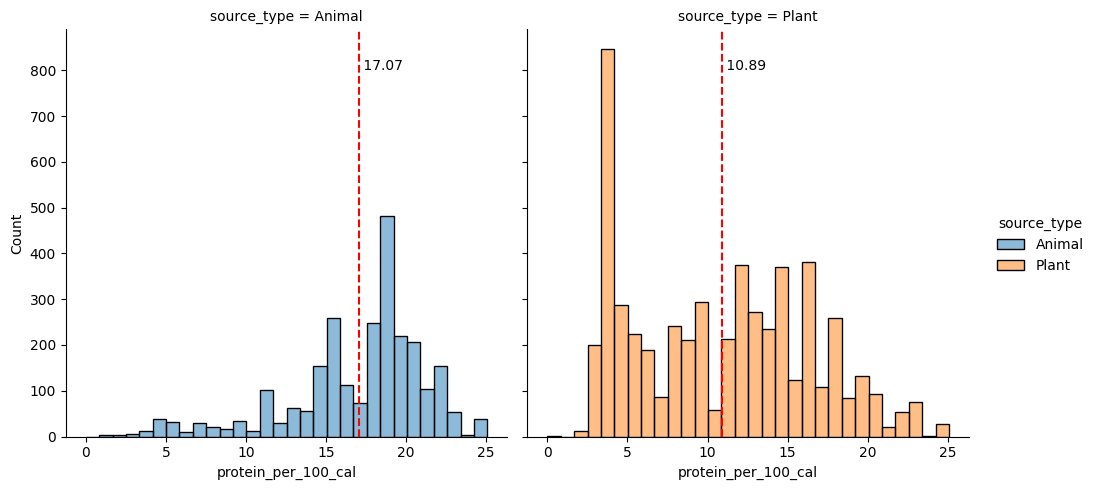

In [68]:
# Create the base displot
g = sns.displot(
    data=labeled_df, 
    x='protein_per_100_cal', 
    col='source_type', 
    hue='source_type', 
    bins=30
)

# Define a function to calculate and draw the mean line
def add_facet_mean(data, **kwargs):
    m = data['protein_per_100_cal'].mean()
    plt.axvline(m, color='red', linestyle='--')
    # Optional: adds the numeric value above the line
    plt.text(m, plt.ylim()[1]*0.9, f' {m:.2f}')

# Map the function to each facet
g.map_dataframe(add_facet_mean)


In [69]:
# Function to clean and count the list
def get_ingredient_count(text):
    if pd.isna(text) or text == '':
        return 0
    # Split by comma and remove any leading/trailing whitespace
    count = len([i for i in text.split(',') if i.strip()])
    return count

# Apply to your DataFrame
labeled_df['ingredient_count'] = labeled_df['ingredients'].apply(get_ingredient_count)


C:\Users\yitho\AppData\Local\Temp\ipykernel_13608\1132962258.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  labeled_df['ingredient_count'] = labeled_df['ingredients'].apply(get_ingredient_count)


In [ ]:
labeled_df['ingredient_count']

np.float64(25.668321747765642)

In [72]:
df_food_nutrient.columns

Index(['id', 'fdc_id', 'nutrient_id', 'amount', 'data_points', 'derivation_id',
       'min', 'max', 'median', 'footnote', 'min_year_acquired'],
      dtype='object')